# Hospital Readmission - Data Exploration

**Author:** Mujtaba Alsabari  
**Notebook:** 01_data_exploration  
**Goal:** Load the dataset, understand its structure, identify data quality issues, and document findings to inform cleaning and modeling decisions.

## Dataset Source
Diabetes 130-US Hospitals (1999-2008), UCI Machine Learning Repository.  
~100,000 hospital encounters of diabetic patients across 130 US hospitals.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully")

Libraries loaded successfully


In [3]:
df = pd.read_csv('../data/raw/diabetic_data.csv')

print(f"Dataset loaded: {df.shape}")

Dataset loaded: (101766, 50)


In [4]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


## Initial observations from `df.head()`

- 50 columns total
- Mix of demographic, clinical, and treatment features
- Diagnosis codes appear to be ICD-9 format (3 columns: diag_1, diag_2, diag_3)
- Many medication columns (binary or categorical)
- Target variable `readmitted` is on the far right
- Some columns show '?' which likely means missing data (will need to verify)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      101766 non-null  str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    101766 non-null  str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                101766 non-null  str  
 11  medical_specialty         101766 non-null  str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

## Column structure summary

The 50 columns can be grouped into logical categories:

| Category | Columns |
|---|---|
| Identifiers | encounter_id, patient_nbr |
| Demographics | race, gender, age, weight |
| Admission/Discharge | admission_type_id, discharge_disposition_id, admission_source_id, time_in_hospital |
| Hospital encounter metrics | num_lab_procedures, num_procedures, num_medications, number_outpatient, number_emergency, number_inpatient |
| Diagnoses | diag_1, diag_2, diag_3, number_diagnoses |
| Lab results | max_glu_serum, A1Cresult |
| Medications | ~24 columns (metformin, insulin, glipizide, etc.) |
| Treatment summary | change, diabetesMed |
| **TARGET** | **readmitted** |

Patients can have multiple encounters (same `patient_nbr` across multiple `encounter_id`s) — important for avoiding data leakage later.

In [6]:
print("Distribution of readmitted column:")
print(df['readmitted'].value_counts())
print("\nAs percentages:")
print(df['readmitted'].value_counts(normalize=True).round(3) * 100)

Distribution of readmitted column:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

As percentages:
readmitted
NO     53.9
>30    34.9
<30    11.2
Name: proportion, dtype: float64


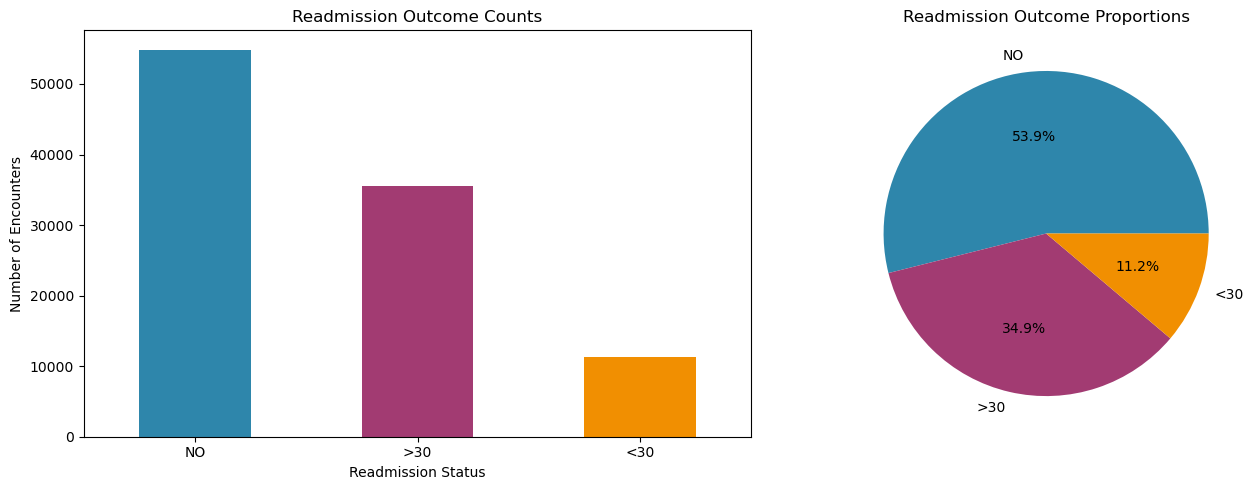

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['readmitted'].value_counts().plot(kind='bar', ax=axes[0], color=['#2E86AB', '#A23B72', '#F18F01'])
axes[0].set_title('Readmission Outcome Counts')
axes[0].set_xlabel('Readmission Status')
axes[0].set_ylabel('Number of Encounters')
axes[0].tick_params(axis='x', rotation=0)

df['readmitted'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', 
                                       colors=['#2E86AB', '#A23B72', '#F18F01'])
axes[1].set_title('Readmission Outcome Proportions')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [8]:
df['readmitted_30d'] = (df['readmitted'] == '<30').astype(int)

print("Binary target (readmitted_30d) distribution:")
print(df['readmitted_30d'].value_counts())
print(f"\nPositive class rate: {df['readmitted_30d'].mean()*100:.2f}%")

Binary target (readmitted_30d) distribution:
readmitted_30d
0    90409
1    11357
Name: count, dtype: int64

Positive class rate: 11.16%


## Target variable findings

The original `readmitted` column has 3 values:
- **NO** — Not readmitted (~54%)
- **>30** — Readmitted after 30 days (~35%)
- **<30** — Readmitted within 30 days (~11%) ← our positive class

### Decision: Binary classification
We define our target as `readmitted_30d`:
- `1` if patient was readmitted within 30 days
- `0` otherwise (including never readmitted, or readmitted after 30 days)

### Key insight: Class imbalance
Only ~11% of encounters end in 30-day readmission. This means:
- A naive model that always predicts "no readmission" would be 89% accurate but useless
- We'll need to use metrics like **recall, precision, F1, and AUC-ROC** rather than just accuracy
- We may need techniques like class weighting, SMOTE, or threshold tuning during modeling

### Clinical relevance
30-day readmission is the right target because:
- CMS (Medicare/Medicaid) financially penalizes hospitals for high 30-day readmission rates under the Hospital Readmissions Reduction Program (HRRP)
- 30 days is medically meaningful — it captures avoidable readmissions related to discharge quality, follow-up care, and medication adherence

In [9]:
print("Standard pandas missing value count:")
print(df.isnull().sum().sum())

Standard pandas missing value count:
181168


In [10]:
question_mark_counts = (df == '?').sum()
question_mark_columns = question_mark_counts[question_mark_counts > 0].sort_values(ascending=False)

print("Columns containing '?' (true missing values):")
print(question_mark_columns)

Columns containing '?' (true missing values):
weight               98569
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
dtype: int64


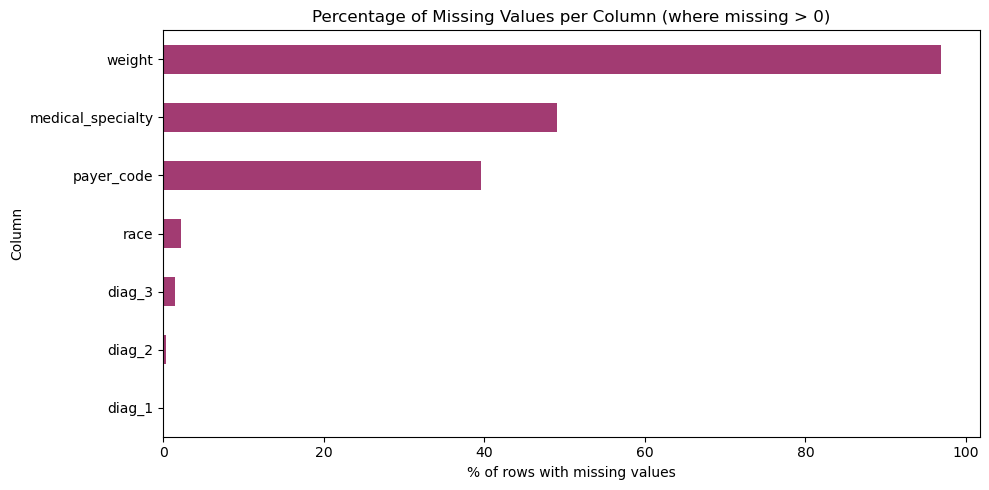

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))

(question_mark_columns / len(df) * 100).plot(kind='barh', ax=ax, color='#A23B72')
ax.set_title('Percentage of Missing Values per Column (where missing > 0)')
ax.set_xlabel('% of rows with missing values')
ax.set_ylabel('Column')
ax.invert_yaxis()  # so the worst column is at the top

plt.tight_layout()
plt.show()

## Missing values findings and decisions

### What we found
The dataset uses `'?'` as a missing value indicator (not `NaN`), which `pandas.isnull()` cannot detect by default. After accounting for this:

| Column | % Missing | Decision |
|---|---|---|
| `weight` | 96.9% | **Drop column** — too sparse to impute reliably |
| `medical_specialty` | 49.1% | **Keep but treat 'Unknown' as a category** — missingness may itself be informative |
| `payer_code` | 39.6% | **Drop column** — likely not predictive of clinical outcome and too sparse |
| `race` | 2.2% | **Impute as 'Other'** — small enough to handle |
| `diag_1`, `diag_2`, `diag_3` | <1.5% each | **Drop those rows** — small impact on dataset size |

### Why these decisions

**Why drop `weight`?**  
With ~97% missing, any imputation we do is essentially making up data. Even median imputation on the remaining 3% would distort the column.

**Why keep `medical_specialty`?**  
"Unknown specialty" might itself signal something — for example, ED visits that bypass specialty assignment. Dropping it would remove potential signal. We'll convert `?` to `'Unknown'` and treat it as a category.

**Why drop `payer_code`?**  
40% missing AND it's an administrative field unlikely to causally drive readmission. Easy decision.

**Why drop rows for missing diagnoses?**  
A patient encounter without a primary diagnosis (`diag_1`) is fundamentally incomplete. We'd rather lose ~21 rows than corrupt our analysis.

In [12]:
# Identify numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remove ID columns - they're meaningless to summarize
id_cols = ['encounter_id', 'patient_nbr']
numeric_cols = [col for col in numeric_cols if col not in id_cols]

print(f"Numeric columns to investigate ({len(numeric_cols)}):")
for col in numeric_cols:
    print(f"  - {col}")

print("\nSummary statistics:")
df[numeric_cols].describe().round(2)

Numeric columns to investigate (12):
  - admission_type_id
  - discharge_disposition_id
  - admission_source_id
  - time_in_hospital
  - num_lab_procedures
  - num_procedures
  - num_medications
  - number_outpatient
  - number_emergency
  - number_inpatient
  - number_diagnoses
  - readmitted_30d

Summary statistics:


,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,readmitted_30d
count,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00
mean,2.02,3.72,5.75,4.40,43.10,1.34,16.02,0.37,0.20,0.64,7.42,0.11
std,1.45,5.28,4.06,2.99,19.67,1.71,8.13,1.27,0.93,1.26,1.93,0.31
min,1.00,1.00,1.00,1.00,1.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00
25%,1.00,1.00,1.00,2.00,31.00,0.00,10.00,0.00,0.00,0.00,6.00,0.00
50%,1.00,1.00,7.00,4.00,44.00,1.00,15.00,0.00,0.00,0.00,8.00,0.00
75%,3.00,4.00,7.00,6.00,57.00,2.00,20.00,0.00,0.00,1.00,9.00,0.00
max,8.00,28.00,25.00,14.00,132.00,6.00,81.00,42.00,76.00,21.00,16.00,1.00


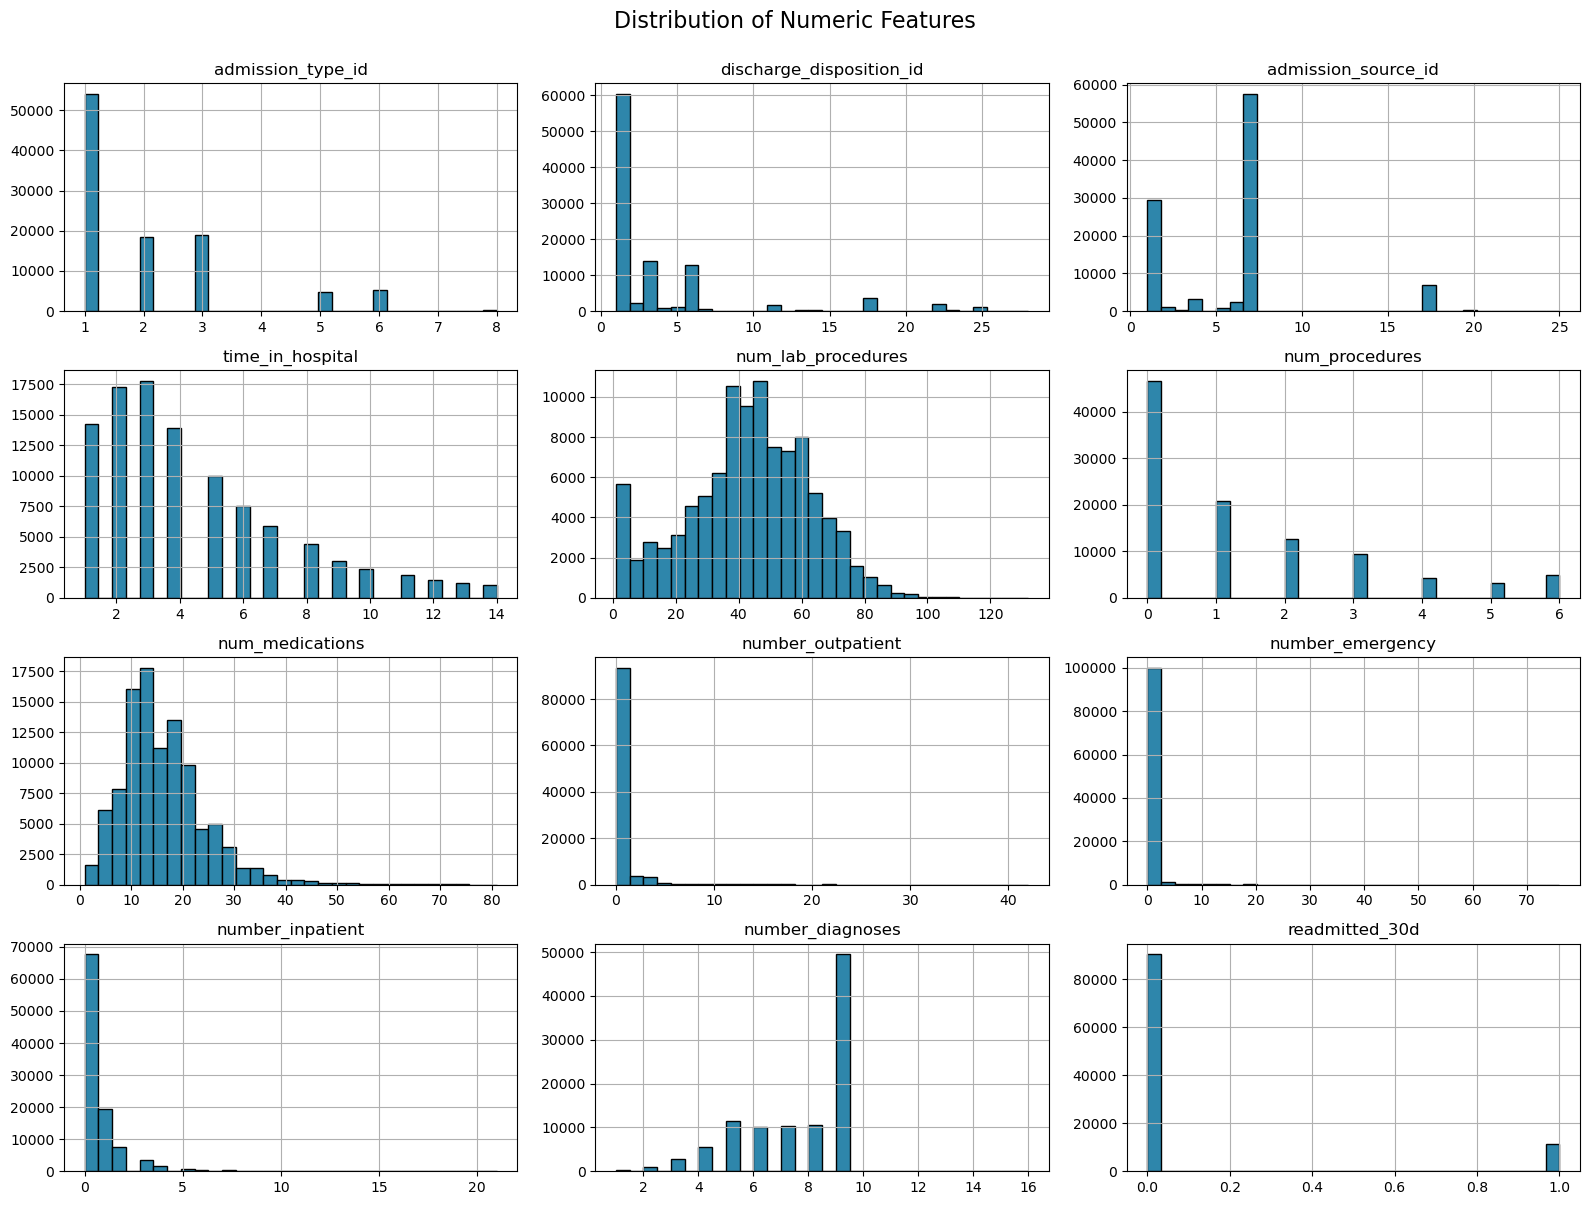

In [13]:
# Plot histograms for each numeric column to see distributions
df[numeric_cols].hist(bins=30, figsize=(16, 12), color='#2E86AB', edgecolor='black')
plt.suptitle('Distribution of Numeric Features', fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

## Numeric features findings

### Strong right-skew (long tail of high values)
- `time_in_hospital` — most stays are 1-5 days, with rare 14+ day stays
- `num_lab_procedures` — most patients had 30-50 labs, but some have 100+
- `num_medications` — most have <20, but some have 60+
- `number_outpatient`, `number_emergency`, `number_inpatient` — heavily zero-inflated; most patients had 0 prior visits, but some had many

### Decision implications
- These skewed distributions suggest we should consider:
  - **Log transformations** for highly skewed counts before modeling
  - **Clipping or capping** extreme outliers (e.g., cap `number_inpatient` at 95th percentile)
  - **Tree-based models** (Random Forest, XGBoost) handle skewness naturally — may not need transformation if we use them

### Hidden categoricals
- `admission_type_id`, `discharge_disposition_id`, `admission_source_id` are encoded as integers but are actually **categorical codes**. The IDS_mapping.csv file translates them. We'll need to either map them to text labels or treat them as categorical despite the int dtype.

In [14]:
# unique diagnosis codes exist 
print(f"Unique diag_1 codes: {df['diag_1'].nunique()}")
print(f"Unique diag_2 codes: {df['diag_2'].nunique()}")
print(f"Unique diag_3 codes: {df['diag_3'].nunique()}")

print("\nTop 10 most common primary diagnoses (diag_1):")
print(df['diag_1'].value_counts().head(10))

Unique diag_1 codes: 717
Unique diag_2 codes: 749
Unique diag_3 codes: 790

Top 10 most common primary diagnoses (diag_1):
diag_1
428    6862
414    6581
786    4016
410    3614
486    3508
427    2766
491    2275
715    2151
682    2042
434    2028
Name: count, dtype: int64


In [15]:
# Get all str columns
categorical_cols = df.select_dtypes(include=['str']).columns.tolist()
# Exclude target and our derived target
categorical_cols = [col for col in categorical_cols if col not in ['readmitted']]

print(f"Categorical columns ({len(categorical_cols)}):\n")
print(f"{'Column':<25} {'Unique Values':>15}")
print("-" * 42)
for col in categorical_cols:
    print(f"{col:<25} {df[col].nunique():>15}")

Categorical columns (36):

Column                      Unique Values
------------------------------------------
race                                    6
gender                                  3
age                                    10
weight                                 10
payer_code                             18
medical_specialty                      73
diag_1                                717
diag_2                                749
diag_3                                790
max_glu_serum                           3
A1Cresult                               3
metformin                               4
repaglinide                             4
nateglinide                             4
chlorpropamide                          4
glimepiride                             4
acetohexamide                           2
glipizide                               4
glyburide                               4
tolbutamide                             2
pioglitazone                            4
rosigl

In [16]:
# Inspect a few key categorical columns more closely
key_cols = ['race', 'gender', 'age', 'A1Cresult', 'max_glu_serum', 'change', 'diabetesMed']

for col in key_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))


--- race ---
race
Caucasian          76099
AfricanAmerican    19210
?                   2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

--- gender ---
gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

--- age ---
age
[70-80)     26068
[60-70)     22483
[50-60)     17256
[80-90)     17197
[40-50)      9685
[30-40)      3775
[90-100)     2793
[20-30)      1657
[10-20)       691
[0-10)        161
Name: count, dtype: int64

--- A1Cresult ---
A1Cresult
NaN     84748
>8       8216
Norm     4990
>7       3812
Name: count, dtype: int64

--- max_glu_serum ---
max_glu_serum
NaN     96420
Norm     2597
>200     1485
>300     1264
Name: count, dtype: int64

--- change ---
change
No    54755
Ch    47011
Name: count, dtype: int64

--- diabetesMed ---
diabetesMed
Yes    78363
No     23403
Name: count, dtype: int64


## Categorical features findings

### High-cardinality challenges
- Diagnosis codes (`diag_1`, `diag_2`, `diag_3`) have 700-800 unique values each
- Naive one-hot encoding would create ~2,400 binary columns → curse of dimensionality
- **Decision:** Group ICD-9 codes into broader categories (e.g., circulatory, respiratory, endocrine, injury) following standard clinical groupings

### Pre-binned numeric features
- `age` is given as `[0-10)`, `[10-20)`, ... rather than raw numbers
- Treat as ordinal (preserving order) rather than nominal (random) categories

### Clinically rich features
- `A1Cresult` and `max_glu_serum` have a meaningful "None" category indicating the test wasn't performed — clinically informative, retain
- `change` (medication change during stay) and `diabetesMed` (on diabetes meds) are simple binary-like features, low cleaning burden
- ~24 individual medication columns each have only 4 levels (No / Steady / Up / Down) — manageable

### Encoding strategy preview
- Demographics (race, gender, age): one-hot or ordinal as appropriate
- Medications: ordinal encoding (since "Up"/"Down" represent direction of change)
- Lab results: preserve "None" as a category
- Diagnoses: group → then one-hot

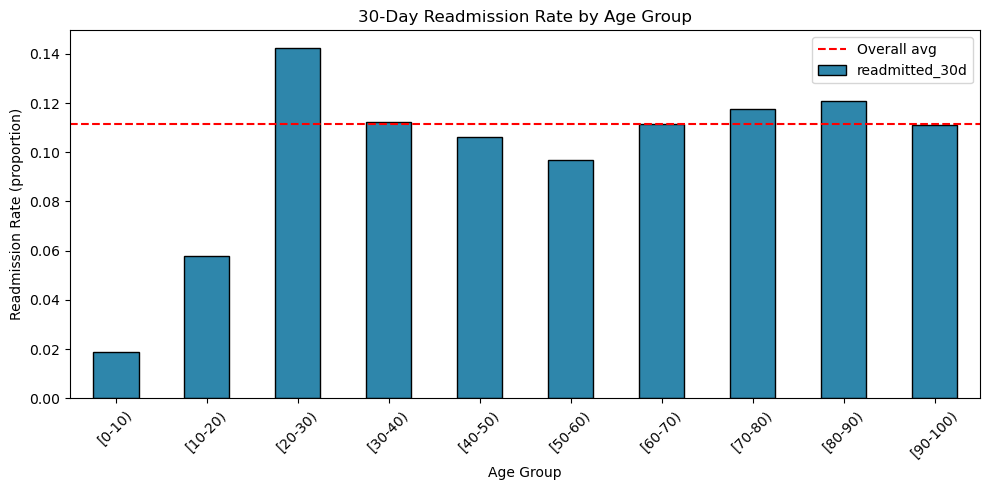

In [17]:
# How does 30-day readmission rate vary by age group?
age_readmit = df.groupby('age')['readmitted_30d'].mean().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
age_readmit.plot(kind='bar', ax=ax, color='#2E86AB', edgecolor='black')
ax.set_title('30-Day Readmission Rate by Age Group')
ax.set_xlabel('Age Group')
ax.set_ylabel('Readmission Rate (proportion)')
ax.axhline(y=df['readmitted_30d'].mean(), color='red', linestyle='--', label='Overall avg')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

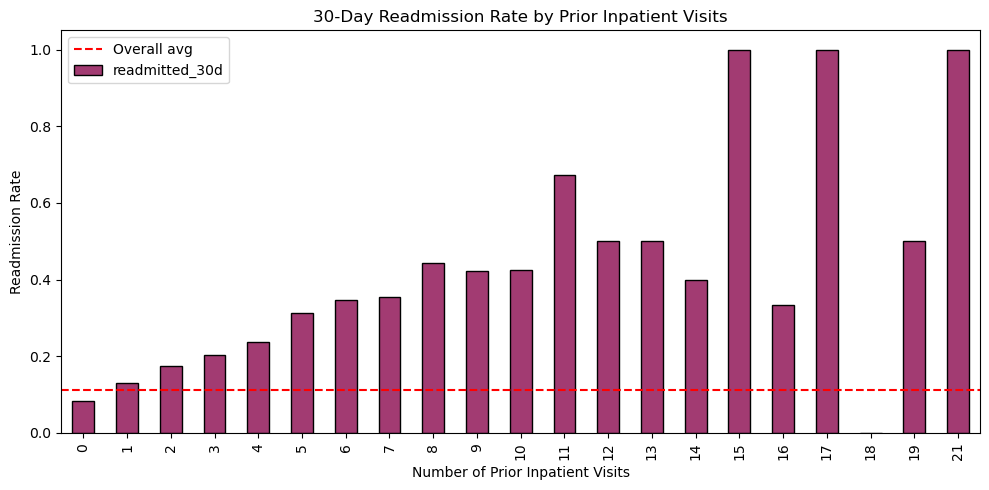

In [18]:
# Patients with prior inpatient stays — are they more likely to readmit?
inpatient_readmit = df.groupby('number_inpatient')['readmitted_30d'].mean()

fig, ax = plt.subplots(figsize=(10, 5))
inpatient_readmit.plot(kind='bar', ax=ax, color='#A23B72', edgecolor='black')
ax.set_title('30-Day Readmission Rate by Prior Inpatient Visits')
ax.set_xlabel('Number of Prior Inpatient Visits')
ax.set_ylabel('Readmission Rate')
ax.axhline(y=df['readmitted_30d'].mean(), color='red', linestyle='--', label='Overall avg')
ax.legend()
plt.tight_layout()
plt.show()

In [19]:
# A1C result is a key diabetes marker — does it predict readmission?
a1c_readmit = df.groupby('A1Cresult')['readmitted_30d'].mean()
a1c_counts = df['A1Cresult'].value_counts()

print("Readmission rates by A1C result:")
result_table = pd.DataFrame({
    'count': a1c_counts,
    'readmit_rate': a1c_readmit
}).sort_values('count', ascending=False)
print(result_table.round(3))

Readmission rates by A1C result:
           count  readmit_rate
A1Cresult                     
>8          8216         0.099
Norm        4990         0.097
>7          3812         0.100


## Phase 2 wrap-up: Findings and decisions for cleaning phase

### Dataset overview
- 101,766 hospital encounters across 50 features
- Target: 30-day readmission (binary), 11.2% positive class — **imbalanced**
- ~70,000 unique patients; some have multiple encounters

### Data quality issues identified
1. Missing values disguised as `'?'`
2. Three columns >40% missing — drop `weight`, `payer_code`; keep `medical_specialty` with "Unknown" category
3. Small missing rates in `race` and diagnosis codes — impute or drop rows
4. Several "ID" columns are actually categorical despite int dtype

### Cleaning plan for next phase
1. **Replace `'?'` with `NaN`** globally
2. **Drop columns**: `weight`, `payer_code` (too sparse); `encounter_id` (identifier only)
3. **Handle missing**: impute `race` as 'Other'; convert `medical_specialty` `'?'` to `'Unknown'`; drop rows missing `diag_1`
4. **Patient-level deduplication**: keep only the *first* encounter per patient (avoid data leakage where the model "sees" the same patient in train and test sets)
5. **Group ICD-9 codes**: collapse `diag_1`/`diag_2`/`diag_3` into broader clinical categories
6. **Recast hidden categoricals**: explicitly convert `admission_type_id`, `discharge_disposition_id`, `admission_source_id` to category dtype
7. **Filter discharge dispositions**: exclude patients who died or went to hospice (they cannot be "readmitted")

### Modeling plan preview
- Try logistic regression (interpretable baseline), random forest, XGBoost
- Use stratified train/test split (preserve 11% positive class ratio)
- Evaluate with AUC-ROC, precision, recall, F1 — NOT accuracy alone
- Apply class weighting to handle imbalance
- Use SHAP for per-prediction explanation in deployment

### Open questions
- Should we use only the **first encounter** per patient, or include all encounters with patient as a fold-grouping variable for cross-validation?
- For diagnosis grouping, use a 9-category clinical scheme (Strack et al. 2014) or a finer 18-category scheme?
- Should we drop the ~3,500 encounters where the patient died/went to hospice, or keep them as definite "no-readmit"?

These are deliberate questions — not blockers. We'll document our choice with a justification when we commit to one in cleaning.